# パッケージのインストール

In [1]:
# パッケージのインストール
list.of.packages <- c("rTensor", "nnTensor",
    "RColorBrewer", "TeachingDemos")
new.packages <- list.of.packages[!(list.of.packages %in% installed.packages()[,"Package"])]
if(length(new.packages)){
    install.packages(new.packages,
        repos="https://cloud.r-project.org/", type="source")
}

# パッケージの読み込み

In [2]:
library("rTensor")
library("nnTensor")
library("RColorBrewer")
library("TeachingDemos")

Warning message:
“no DISPLAY variable so Tk is not available”


# 定数の設定

In [3]:
N_SUBJECTS <- 10       # 使用する被験者数
IMG_DIM <- c(92, 112)  # 顔画像の画素数 (幅 x 高さ)

# 関数定義

In [4]:
# 顔画像を2x5グリッドで表示する関数
plot_faces <- function(tensor, slice, colvec){
    layout(rbind(1:5, 6:10))
    for(i in seq(N_SUBJECTS)){
        image(tensor@data[,,i,slice], col=colvec, main=i)
    }
}

# 行列分解の係数（基底画像）を表示する関数
plot_coef <- function(coef_matrix, colvec){
    layout(rbind(1:5, 6:10))
    for(i in seq(N_SUBJECTS)){
        tmp <- as.matrix(coef_matrix[,i])
        dim(tmp) <- IMG_DIM
        image(tmp, col=rev(colvec), main=i)
    }
}

# スコア（各被験者の重み）を2次元散布図で表示する関数
plot_score <- function(score_matrix, facedata, colvec){
    plot(score_matrix[,1:2], pch=16, cex=2,
        axes=FALSE, xlab="", ylab="")
    abline(v=0)
    abline(h=0)
    for(i in seq(N_SUBJECTS)){
        subplot(image(facedata@data[,,i,1], col=colvec,
            main=i, axes=FALSE),
            x=score_matrix[i,1], y=score_matrix[i,2],
            size=c(0.45, 0.45))
    }
}

# カラーパレットの設定

In [5]:
colvec <- rev(brewer.pal(9, "Greys"))

# ORL顔画像データのダウンロード

10人×40枚×10角度の4階テンソルとして格納されている。

In [6]:
options(timeout = 600)
facedata <- load_orl()
str(facedata)

Formal class 'Tensor' [package ".GlobalEnv"] with 3 slots
  ..@ num_modes: int 4
  ..@ modes    : int [1:4] 92 112 40 10
  ..@ data     : num [1:92, 1:112, 1:40, 1:10] 0.2 0.2 0.2 0.176 0.204 ...


# 顔画像の表示（角度1）

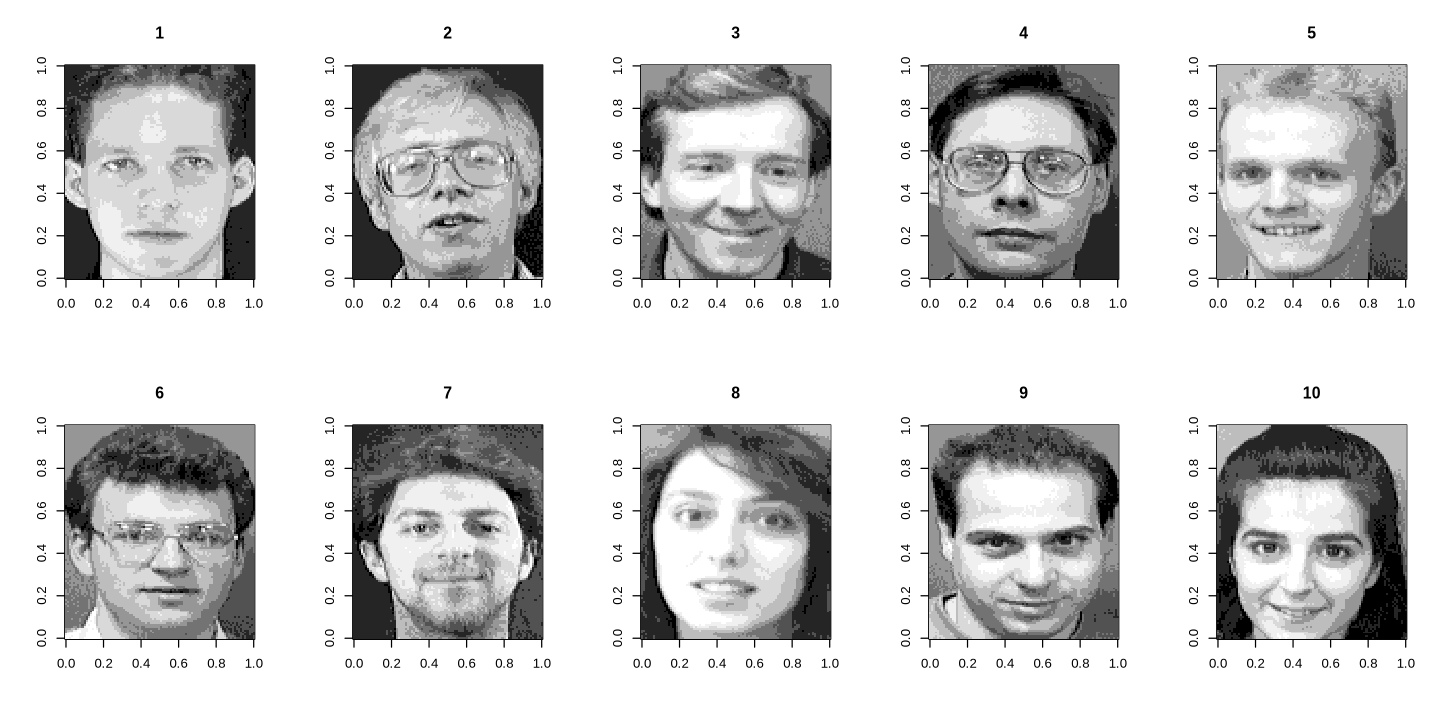

In [7]:
options(repr.plot.width=12, repr.plot.height=6)
plot_faces(facedata, slice=1, colvec)

# 顔画像の表示（角度2）

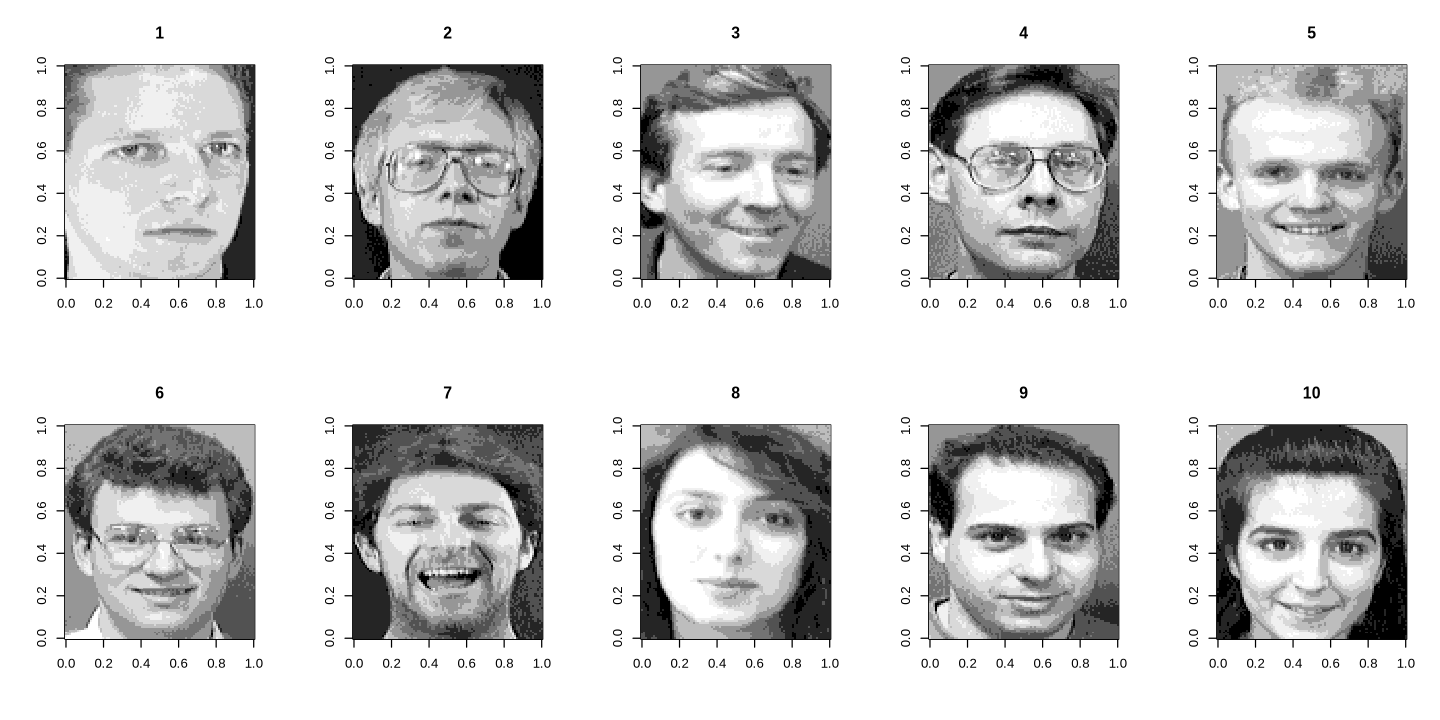

In [8]:
options(repr.plot.width=12, repr.plot.height=6)
plot_faces(facedata, slice=2, colvec)

# テンソルの3モード展開により行列化

10人分、角度1のみ使用する。

In [9]:
matdata <- cs_unfold(facedata[,,1:N_SUBJECTS,1], m=3)@data

# 平均顔の計算と表示

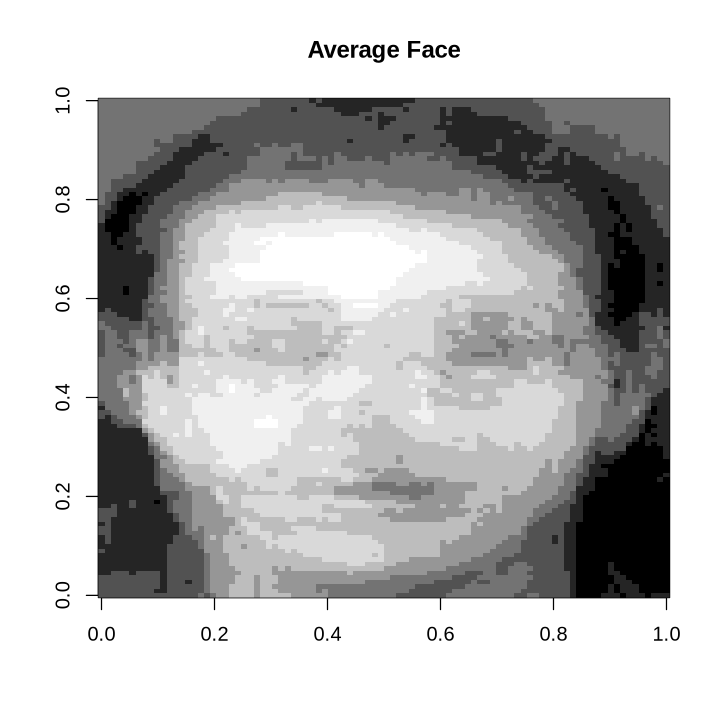

In [10]:
options(repr.plot.width=6, repr.plot.height=6)
average_face <- rowMeans(matdata)
dim(average_face) <- IMG_DIM
image(average_face, col=colvec, main="Average Face")

# PCA（主成分分析）

In [11]:
res_pca <- prcomp(t(matdata), center=TRUE, scale=FALSE)

## PCAの係数（固有顔）の表示

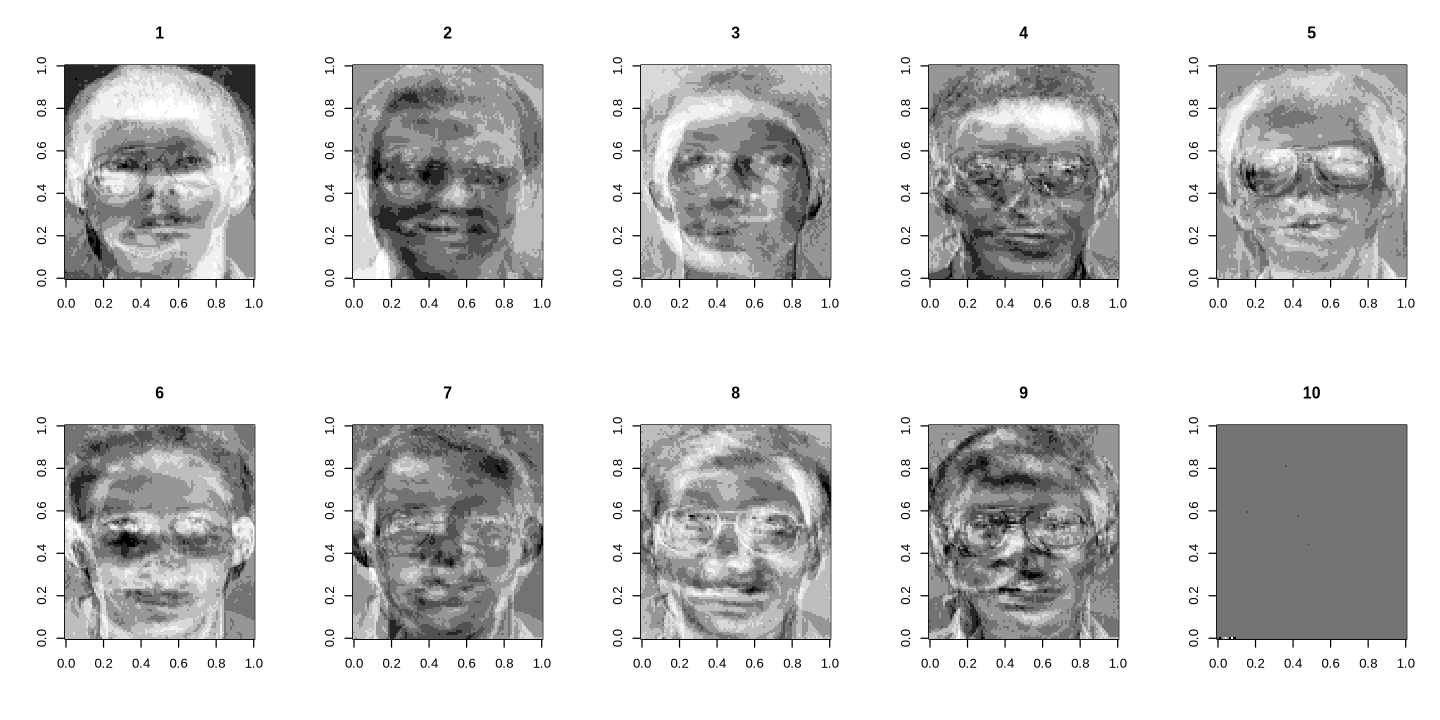

In [12]:
options(repr.plot.width=12, repr.plot.height=6)
plot_coef(res_pca$rotation, colvec)

## PCAのスコアの表示

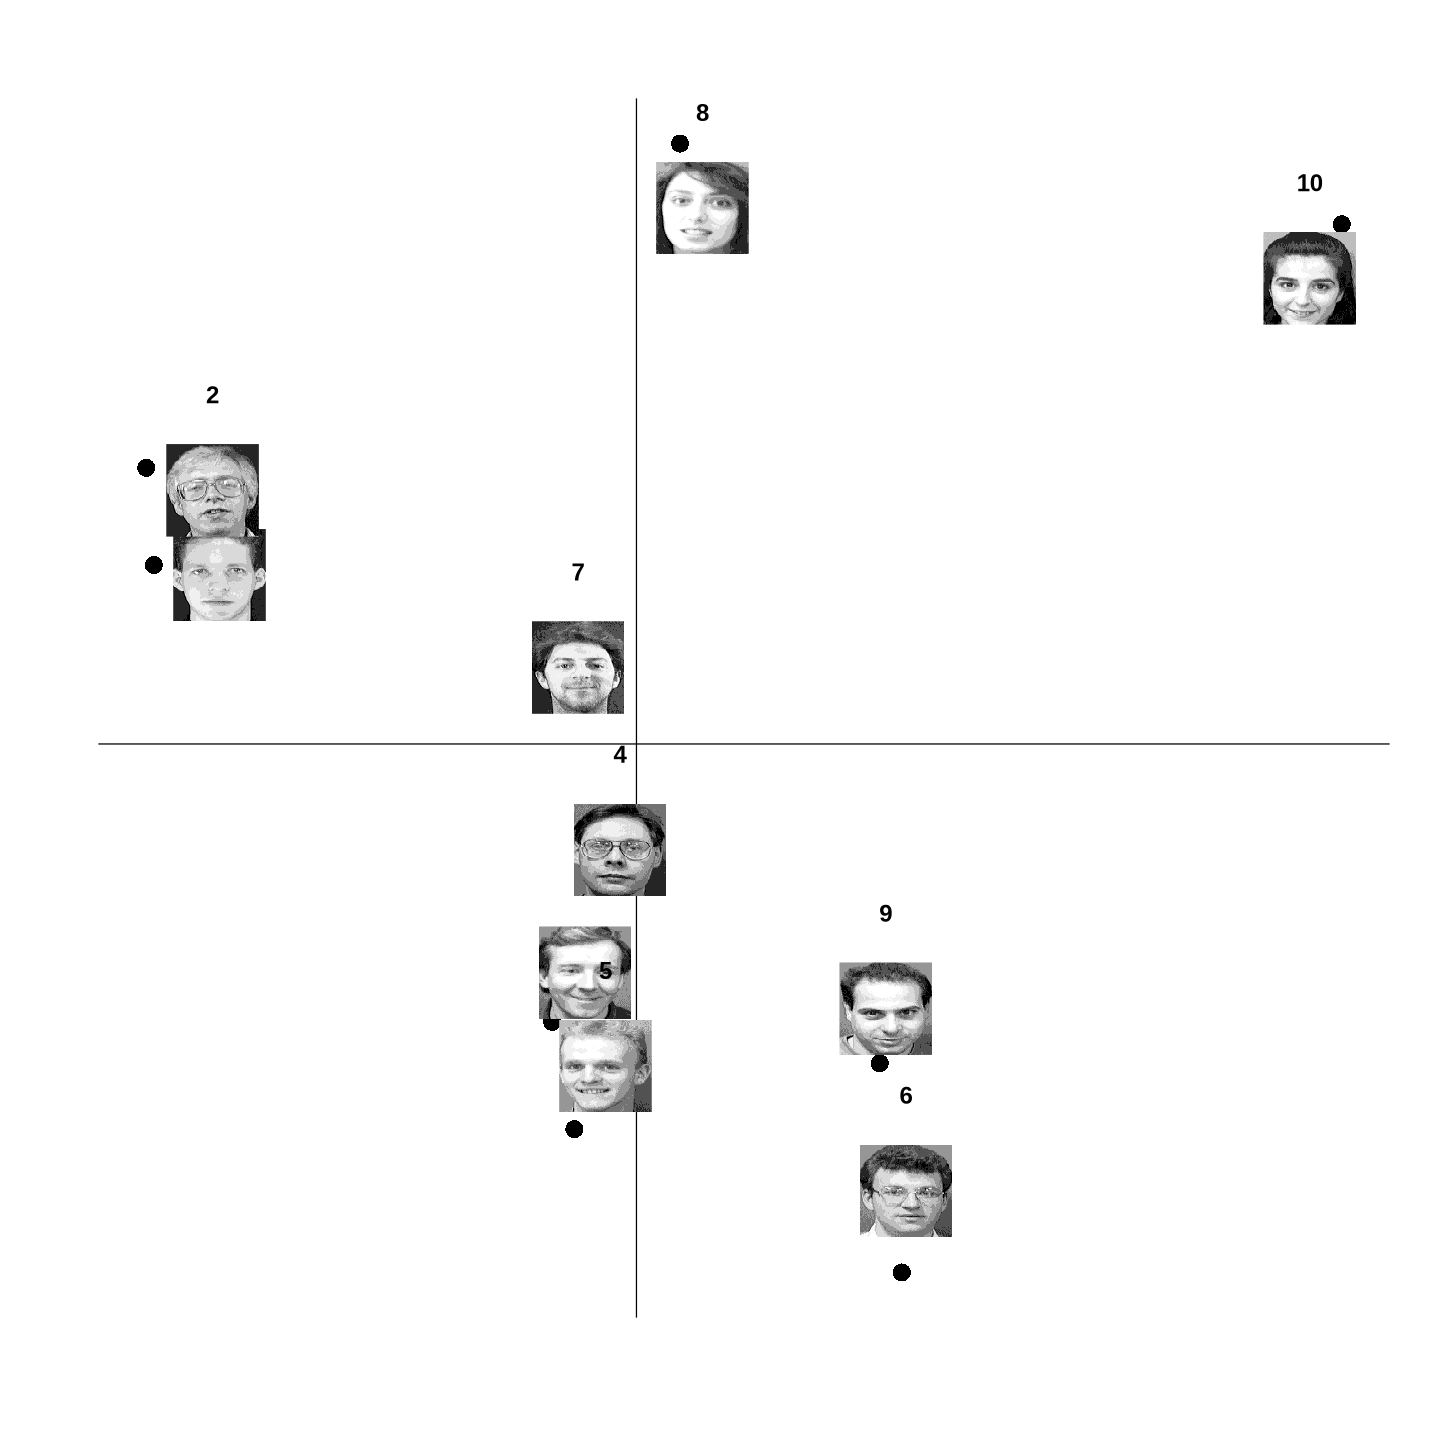

In [13]:
options(repr.plot.width=12, repr.plot.height=12)
plot_score(res_pca$x, facedata, colvec)

# NMF（非負値行列因子分解）

In [14]:
res_nmf <- NMF(matdata, J=N_SUBJECTS)

## NMFの係数（基底画像）の表示

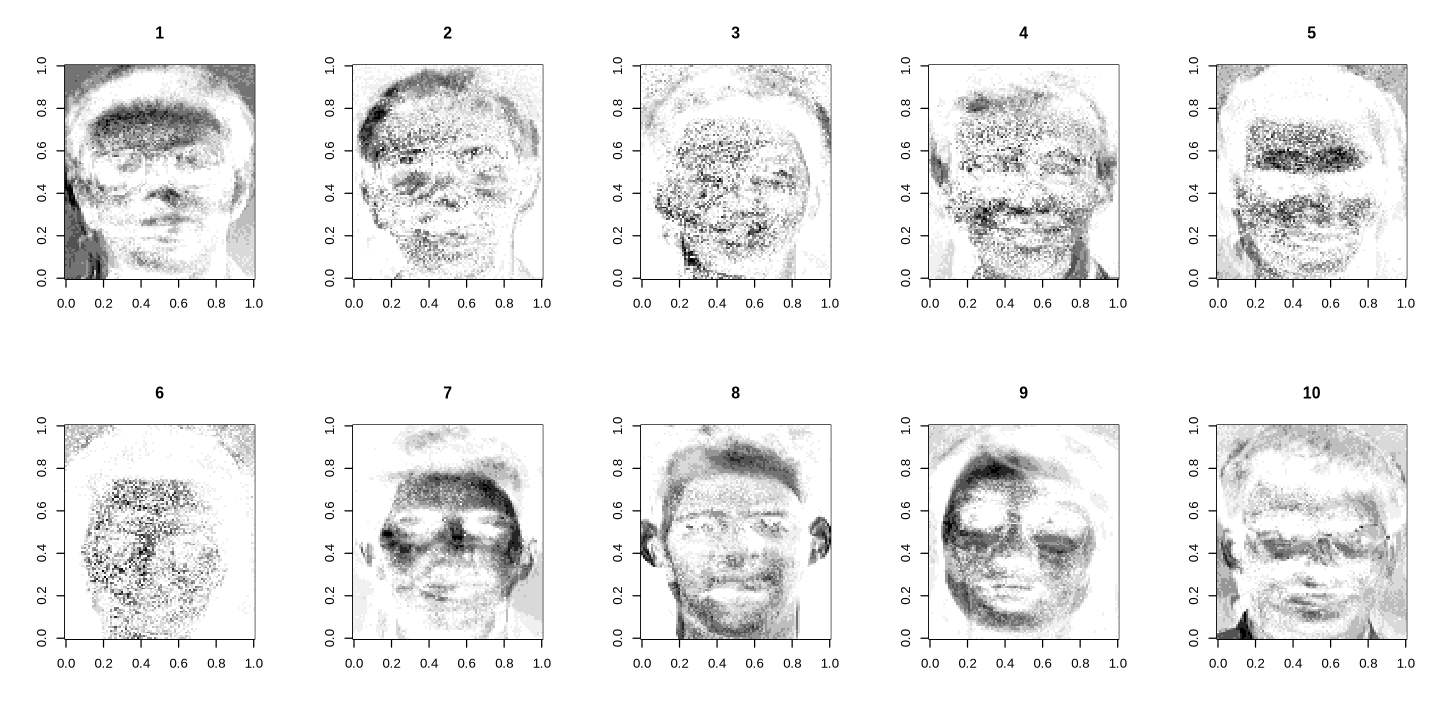

In [15]:
options(repr.plot.width=12, repr.plot.height=6)
plot_coef(res_nmf$U, colvec)

## NMFのスコアの表示

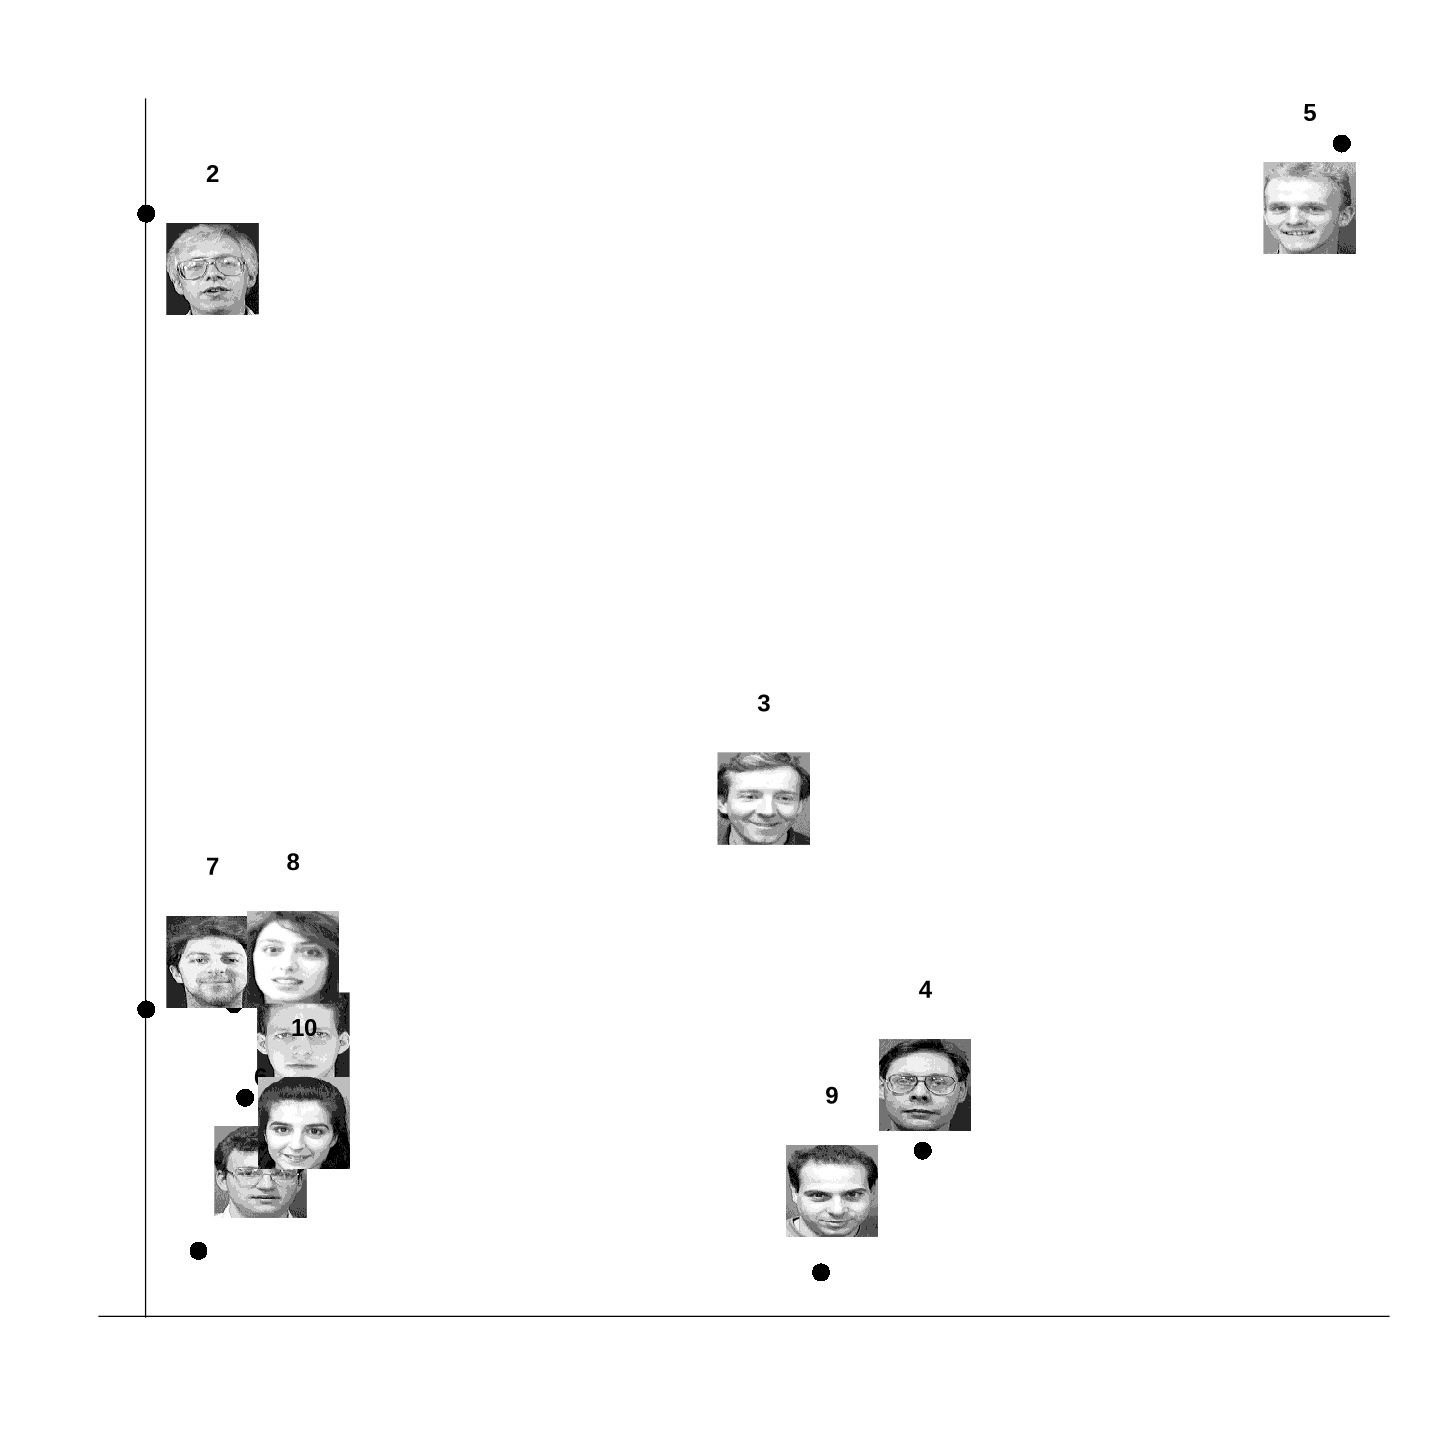

In [16]:
options(repr.plot.width=12, repr.plot.height=12)
plot_score(res_nmf$V, facedata, colvec)

# セッション情報

In [17]:
sessionInfo()

R version 4.5.3 (2026-03-11)
Platform: x86_64-conda-linux-gnu
Running under: Rocky Linux 9.5 (Blue Onyx)

Matrix products: default
BLAS/LAPACK: /home/koki/miniconda3/envs/r-notebook/lib/libopenblasp-r0.3.32.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Asia/Tokyo
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] TeachingDemos_2.13 RColorBrewer_1.1-3 nnTensor_1.3.0     rTensor_1.4.9     

loaded via a namespace (and not attached):
 [1] gtable_0.3.6      jsonlite_2.0.0    compiler_4.5.3    crayon_1.5.3     
 [5] maps_3.4.3        R